## Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from classy import Class

### Importing from files

In [2]:
import sys
import os

# Add the parent directory to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Now import the module
from relativistic_degrees_of_freedom import RelativisticDegreesOfFreedom

In [3]:
# Now import module: evaluate A(log(m_a)), b(log(m_a)) and mu(log(m_a)) for muon scattering
from axion_production.taon_decay import evaluate_parameter

## Find today temperature of axion: $T_{\mathrm{ncdm}}$

More details about this calculation can be found in 2211.03799 on page: 13.

In [4]:
RelativisticDOF = RelativisticDegreesOfFreedom()

In [5]:
# --- Set axion process of production and corresponding dof ---
taon_mass = 1777*10**6  # [eV]
taon_mass_MeV = 1777 # [MeV]
x_dec_taon = 30  # decouple from the plasma
axion_decouple_dof = RelativisticDOF.compute_decoupling_dof(taon_mass, x_dec_taon)
print(f"taon mass: {taon_mass_MeV} [MeV], corresponds to: {axion_decouple_dof} relativistic dof of entropy")

# Set neutrinos decouple temperature and find corresponding dof
neutrino_decouple_T = 3*10**6  # 8.617 * 10**(-5) * 2.725, 3*10**6, [eV]
neutrino_decouple_dof = RelativisticDOF.get_degrees_of_freedom(neutrino_decouple_T, dof_type="g_eff_s")
print(f"kB*T for neutrino decouple: {neutrino_decouple_T*10**(-6)} [MeV]," 
      f"corresponds to: {neutrino_decouple_dof} relativistic dof of entropy")

taon mass: 1777 [MeV], corresponds to: 14.989432584994862 relativistic dof of entropy
kB*T for neutrino decouple: 3.0 [MeV],corresponds to: 10.721487622640407 relativistic dof of entropy


In [6]:
g_s_star_ratio = (neutrino_decouple_dof/axion_decouple_dof)
print("g_s_star_ratio:", g_s_star_ratio)

g_s_star_ratio: 0.7152697449917569


In [7]:
def calculate_T_axion(_g_s_star_ratio):
    """
    Calculate temperature of axion in selected process of production. For our reference
    T_nu = 0.71611 [T_gamma] is temperature of neutrinos. Variables `_g_s_star_ratio`:
    is the ratio between entropy degrees of freedom (dof) of axion (in moment of decople)
    and neutrinos (in moment of decouple).
    """
    return 0.71611 * (_g_s_star_ratio)**(1/3) # in units of photon temperature [T_gamma]

## CLASS PART: Base parameters setting (we do not vary them)

In [8]:
# --- Define the cosmological parameters for LambdaCDM + neutrinos + axions ---
params = {
    'output': 'mPk',  # Output: matter power spectrum
    'P_k_max_1/Mpc': 3.0,  # Maximum wavenumber for the power spectrum
    'h': 0.67556,          # Reduced Hubble parameter
    'omega_b': 0.022032,   # Baryon density
    'omega_cdm': 0.12038,  # Cold dark matter density
    'n_s': 0.9619,         # Spectral index
    'A_s': 2.215e-9,       # Amplitude of scalar perturbations
    'tau_reio': 0.0925,    # Optical depth to reionization

    # Neutrino and axion related parameters
    'N_ur': 0.0,
    'N_ncdm': '2',              # two species: neutrinos and axions
    'deg_ncdm': '3, 1',         # 3 degenerate neutrinos and axion

    # Basic settings
    # 'use_ncdm_psd_files': '0, 0',
    
    # Extra settings
    # 'perturbed_recombination': 'yes',       # consider perturbed recombination
    # 'ceff2_ur': 1/3,                        # effective squared sound speed and viscosity parameter
    # 'cvis2_ur': 1/3,                        # effective squared sound speed and viscosity parameter
    'ncdm_quadrature_strategy': '0, 0',      # is the method used for the momentum sampling of the ncdm distribution function: 0, 1, 2, 3
    # 'ncdm_maximum_q': '15, 15'
}

In [9]:
# the range of parameters, which we gonna investigate
max_axion_mass = 5.69    # [eV]
min_axion_mass = 0.0569  # [eV]
Nums = 100
axion_masses = np.logspace(np.log10(min_axion_mass), np.log10(max_axion_mass), num=Nums)  # [eV]
nuetrino_mass = 0.006  # [eV]
T_neutrinos = 0.71611  # in units of photon temperature [T_gamma]
# print(axion_masses)

# prepare list
Neff_base = 3.039594664360296
deltaNeff_list = []

### Varied parameters (axion masses and distribution)

In [10]:
cosmo_dict = {}
#
for i in range(0, Nums):
    # --- Find physcial values
    m_a = axion_masses[i]  # [eV]
    log_m_a = np.log(m_a)  # [log(eV)]
    T_axion = calculate_T_axion(g_s_star_ratio) # in units of photon temperature [T_gamma]

    # --- Find parameters for selected axion masses
    A = evaluate_parameter("A", log_m_a)
    b = evaluate_parameter("b", log_m_a)
    mu = evaluate_parameter("mu", log_m_a)
    
    # --- Call CLASS
    if i % 10 == 0:
        print("I'm calculate for:", m_a, "[eV]", T_axion, "[T_gamma], index:", i)

    cosmo_dict[i] = Class()
    cosmo_dict[i].set(params)
    cosmo_dict[i].set({'m_ncdm': f'{nuetrino_mass}, {m_a}'})     # Masses of neutino and axion
    cosmo_dict[i].set({'T_ncdm': f'{T_neutrinos}, {T_axion}'})   # Temperature of neutino and axion
    cosmo_dict[i].set({'ncdm_psd_parameters': f'{A},{b},{mu}'})  # Axion distribution function
    cosmo_dict[i].compute()

I'm calculate for: 0.05689999999999999 [eV] 0.6404270839973406 [T_gamma], index: 0
I'm calculate for: 0.09060089094110814 [eV] 0.6404270839973406 [T_gamma], index: 10
I'm calculate for: 0.14426223970689936 [eV] 0.6404270839973406 [T_gamma], index: 20
I'm calculate for: 0.22970628201414395 [eV] 0.6404270839973406 [T_gamma], index: 30
I'm calculate for: 0.3657573603734779 [eV] 0.6404270839973406 [T_gamma], index: 40
I'm calculate for: 0.5823891514605459 [eV] 0.6404270839973406 [T_gamma], index: 50
I'm calculate for: 0.9273282248991465 [eV] 0.6404270839973406 [T_gamma], index: 60
I'm calculate for: 1.4765687762864503 [eV] 0.6404270839973406 [T_gamma], index: 70
I'm calculate for: 2.3511150556656273 [eV] 0.6404270839973406 [T_gamma], index: 80
I'm calculate for: 3.743640048301563 [eV] 0.6404270839973406 [T_gamma], index: 90


In [11]:
# --- Finding all deltaNeff values
for i in range(0, Nums):
    derived_params = cosmo_dict[i].get_current_derived_parameters(['Neff'])  # derived parameters
    deltaNeff = derived_params['Neff'] - Neff_base
    deltaNeff_list.append(deltaNeff)

print("lowest value of \Delta N_eff:", min(deltaNeff_list))

lowest value of \Delta N_eff: 0.09595987499588254


## Extra Relativistic Degrees of Freedom and Axion Mass: $\Delta N_{\mathrm{eff}}(m_\mathrm{a})$

In [12]:
def calculate_fa(ma):
    """
    Calculate the f_a value from a given axion mass m_a in eV based on the axion mass
    formula from particle physics. The relationship between the axion decay constant f_a
    and the axion mass m_a is given by the specific scale factor derived from theoretical
    models which predict f_a inversely proportional to m_a.

    This specific formula is referenced from a particle physics review publication:
    https://pdg.lbl.gov/2023/reviews/rpp2023-rev-axions.pdf

    Parameters:
    ma (float): The mass of the axion in eV.

    Returns:
    float: The axion decay constant f_a in GeV.
    """
    fa = (5.691 * 10 ** 6) / ma  # [GeV]
    return fa  # [GeV]

In [13]:
# Find decay constants: f_a
decay_constants = calculate_fa(axion_masses)

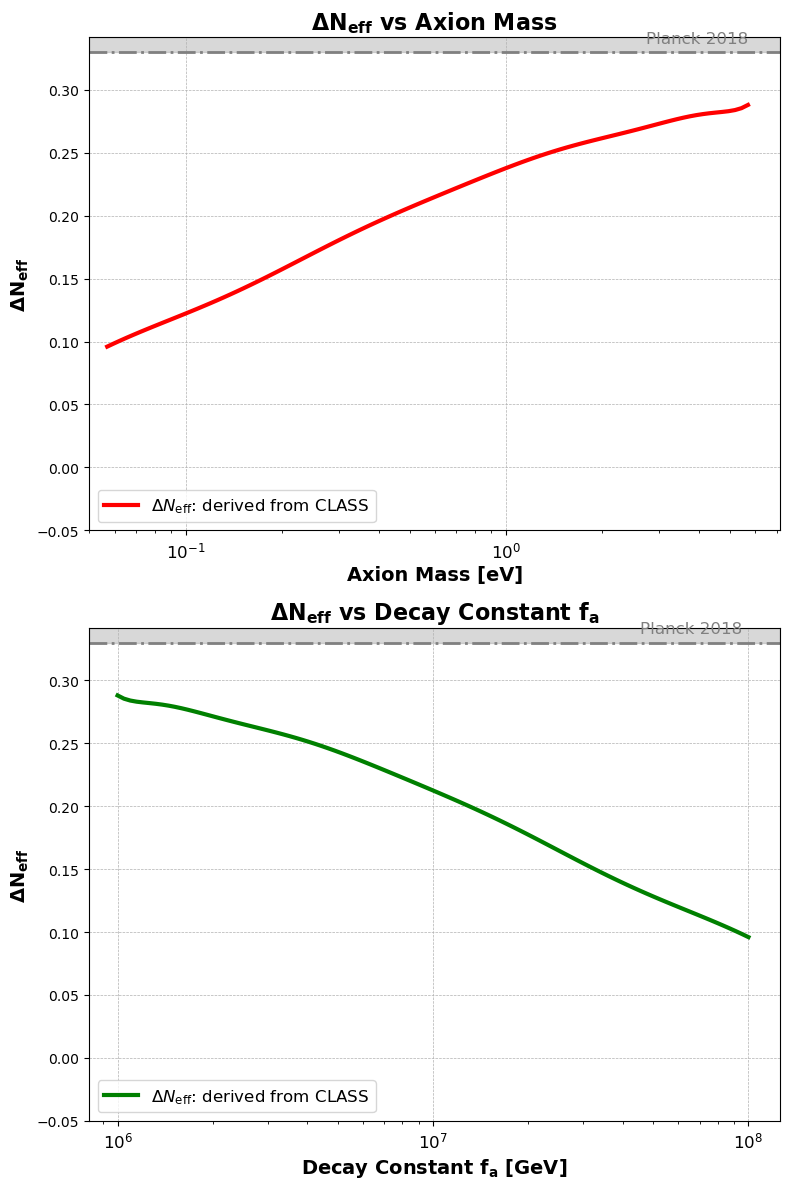

In [14]:
# Create the figure with improved aesthetics
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

# ---------------------------------------------------- FIRST PART OF PLOT ---------------------------------------------------- #
# Plot the original data points
axs[0].plot(axion_masses, deltaNeff_list, color='r', label=r'$\Delta N_{\rm{eff}}$: derived from CLASS', lw=3)
axs[0].set_xscale('log')
axs[0].set_xlabel('Axion Mass [eV]', fontsize=14, fontweight='bold')
axs[0].set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
axs[0].set_title(r'$\bf \Delta N_{eff}$ vs Axion Mass', fontsize=16, fontweight='bold')
axs[0].grid(True, linestyle='--', linewidth=0.5)
axs[0].legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33

# Add dashed-dotted line for Planck 2018 limit
axs[0].axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text for Planck 2018 directly on the plot
axs[0].text(axion_masses[-1], planck_limit + 0.005, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = axs[0].get_ylim()
xmin, xmax = axs[0].get_xlim()
xmin = 0.05
axs[0].set_xlim(xmin, xmax)
axs[0].set_ylim(-0.05, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
axs[0].fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
axs[0].xaxis.set_major_locator(ticker.LogLocator(base=10.0))
axs[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
axs[0].tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# ---------------------------------------------------- SECOND PART OF PLOT ---------------------------------------------------- #
# Second plot: f_a vs Delta_N_eff with larger font size and thicker lines
axs[1].plot(decay_constants, deltaNeff_list, color='g', lw=3, label=r'$\Delta N_{\rm{eff}}$: derived from CLASS')
axs[1].set_xscale('log')
axs[1].set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
axs[1].set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
axs[1].set_title(r'$\bf \Delta N_{eff}$ vs Decay Constant $\bf f_a$', fontsize=16, fontweight='bold')
axs[1].grid(True, linestyle='--', linewidth=0.5)
axs[1].legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33

# Add dashed-dotted line for Planck 2018 limit
axs[1].axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text for Planck 2018 directly on the plot
axs[1].text(decay_constants[1], planck_limit + 0.005, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = axs[1].get_ylim()
xmin, xmax = axs[1].get_xlim()
xmin = calculate_fa(7.0)
axs[1].set_xlim(xmin, xmax)
axs[1].set_ylim(-0.05, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
axs[1].fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
axs[1].xaxis.set_major_locator(ticker.LogLocator(base=10.0))
axs[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
axs[1].tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# ---------------------------------------------------- SAVING PLOT ---------------------------------------------------- #
# Adjust layout and show the plot
plt.tight_layout()
plt.show()
# plt.savefig('Fits_of_delta_N_eff_and_axion_mass.png', format='png', dpi=300)
# plt.close()